In [ ]:
# 安装所需软件包

!pip install -U langgraph langsmith

In [1]:
# langgraph Hello World
from langgraph.prebuilt import create_react_agent
from langchain_community.chat_models import ChatTongyi

llm = ChatTongyi(
    model_name="qwen-turbo",
    temperature=0.7,
    streaming=True
)

agent = create_react_agent(
    model = llm,
    tools = [],
    prompt= "You are a helpful assistant."
)

# agent.invoke({"message":[{"role":"user","content":"Hello, how can I help you?"}]})
for chunk in agent.stream(
    {"message":[{"role":"user","content":"你是谁？"}]},
    stream_mode = "messages"
):
    print(chunk)
    print("\n")



C:\Users\LiuHuijun\AppData\Local\Temp\ipykernel_37620\3451535095.py:11: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent = create_react_agent(


(AIMessageChunk(content='Hello', additional_kwargs={}, response_metadata={}, id='lc_run--019ddef9-b809-79b2-8c6b-3329fe236c04', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'agent', 'langgraph_triggers': ('branch:to:agent',), 'langgraph_path': ('__pregel_pull', 'agent'), 'langgraph_checkpoint_ns': 'agent:f061a1c6-cfad-c358-be18-631eafd55697', 'checkpoint_ns': 'agent:f061a1c6-cfad-c358-be18-631eafd55697', 'ls_provider': 'tongyi', 'ls_model_type': 'chat', 'ls_model_name': 'qwen-turbo'})


(AIMessageChunk(content='!', additional_kwargs={}, response_metadata={}, id='lc_run--019ddef9-b809-79b2-8c6b-3329fe236c04', tool_calls=[], invalid_tool_calls=[], tool_call_chunks=[]), {'langgraph_step': 1, 'langgraph_node': 'agent', 'langgraph_triggers': ('branch:to:agent',), 'langgraph_path': ('__pregel_pull', 'agent'), 'langgraph_checkpoint_ns': 'agent:f061a1c6-cfad-c358-be18-631eafd55697', 'checkpoint_ns': 'agent:f061a1c6-cfad-c358-be18-631eafd55

创建一个 StateGraph 为“状态机”,添加 节点 来表示 LLM 和聊天机器人可以调用的函数，并添加 边 来指定机器人应如何在这些函数之间进行转换。

> 定义：定义图时，第一步是定义其 状态。状态 包括图的模式和处理状态更新的 reducer 函数。在我们的示例中，状态 是一个具有一个键：messages 的 TypedDict。 add_messages reducer 函数用于将新消息追加到列表中，而不是覆盖它。没有 reducer 注解的键将覆盖先前的值。

In [2]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START
from langgraph.graph.message import add_messages

class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

我们的图现在可以处理两个关键任务

每个 节点 都可以接收当前 状态 作为输入，并输出状态的更新。
对 消息 的更新将追加到现有列表而不是覆盖它。


接下来，添加一个“chatbot”节点。 节点 表示工作单元，通常是普通的 Python 函数。

```python
import os
from langchain.chat_models import init_chat_model

os.environ["OPENAI_API_KEY"] = "sk-..."

llm = init_chat_model("openai:gpt-4.1")
```

In [3]:
from langchain_community.chat_models import ChatTongyi
# 或者使用
# from langchain_community.llms import Tongyi

# 设置通义千问的 API Key
# os.environ["DASHSCOPE_API_KEY"] = "your-dashscope-api-key"

# 初始化通义千问模型
llm = ChatTongyi(
    model_name="qwen-turbo",  # 或者 "qwen-plus", "qwen-max"
    temperature=0.7,
    streaming=True
)

将聊天模型集成到一个简单的节点中

In [4]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}


# The first argument is the unique node name
# The second argument is the function or object that will be called whenever
# the node is used.
graph_builder.add_node("chatbot", chatbot)

添加一个 入口 点，以告诉图每次运行时**从何处开始工作**

In [5]:
graph_builder.add_edge(START, "chatbot")

在运行图之前，我们需要对其进行编译。我们可以通过在图构建器上调用 compile() 来完成。这将创建一个 CompiledGraph，我们可以在我们的状态上调用它。

In [6]:
graph = graph_builder.compile()

您可以使用 get_graph 方法和其中一个“绘图”方法（例如 draw_ascii 或 draw_png）来可视化图。这些 draw 方法都需要额外的依赖项。

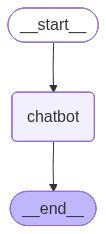

In [7]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

运行聊天机器人,通过键入 quit、exit 或 q 来退出聊天循环。

In [8]:
def stream_graph_updates(user_input: str):
    for event in graph.stream({"messages": [{"role": "user", "content": user_input}]}):
        for value in event.values():
            print("Assistant:", value["messages"][-1].content)


while True:
    try:
        user_input = input("User: ")
        if user_input.lower() in ["quit", "exit", "q"]:
            print("Goodbye!")
            break
        stream_graph_updates(user_input)
    except:
        # fallback if input() is not available
        user_input = "What do you know about LangGraph?"
        print("User: " + user_input)
        stream_graph_updates(user_input)
        break

Assistant: 我是通义千问，是阿里巴巴集团旗下的通义实验室自主研发的超大规模语言模型。我能够回答问题、创作文字、逻辑推理、编程等多种任务。我的中文名是通义千问，英文名是Qwen。如果你有任何问题或需要帮助，欢迎随时告诉我！
Assistant: **量化交易（Quantitative Trading）** 是一种利用数学模型、统计分析和计算机算法来制定和执行交易决策的金融交易方式。它不同于传统的主观交易（如技术分析或基本面分析），而是通过系统化的方法，从大量的历史数据中寻找规律，并基于这些规律进行自动化或半自动化的交易操作。

---

### 一、量化交易的核心要素

1. **数据**  
   - 量化交易依赖于大量历史市场数据（如价格、成交量、财务报表等）。
   - 数据来源包括交易所、第三方数据提供商（如Wind、Bloomberg）、公开市场信息等。

2. **策略**  
   - 量化策略是基于某种逻辑或数学模型设计的交易规则。
   - 常见策略包括：
     - **趋势跟踪（Trend Following）**
     - **均值回归（Mean Reversion）**
     - **套利（Arbitrage）**
     - **因子投资（Factor Investing）**
     - **高频交易（HFT）**

3. **模型与算法**  
   - 使用统计模型、机器学习、深度学习等方法构建预测模型。
   - 例如：使用线性回归预测价格走势、使用随机森林分类器判断买卖信号等。

4. **执行系统**  
   - 自动化交易系统根据策略生成交易指令，并在交易所执行。
   - 包括订单管理、风险控制、回测等功能。

5. **风险管理**  
   - 量化交易非常重视风险控制，包括仓位控制、止损机制、波动率控制等。

---

### 二、量化交易的类型

| 类型 | 特点 | 例子 |
|------|------|------|
| **高频交易（HFT）** | 利用极短时间内的价格波动获利，依赖低延迟的交易平台 | 套利、做市商策略 |
| **程序化交易（Algorithmic Trading）** | 按照预设规则自动执行订单 | 跟踪指数、分批买入/卖出 |
| **统计套利（Stat